In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Shared room']

In [4]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)

C:\Users\issei\AppData\Local\Temp\ipykernel_47456\1014031884.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)


C:\Users\issei\AppData\Local\Temp\ipykernel_47456\2518764000.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


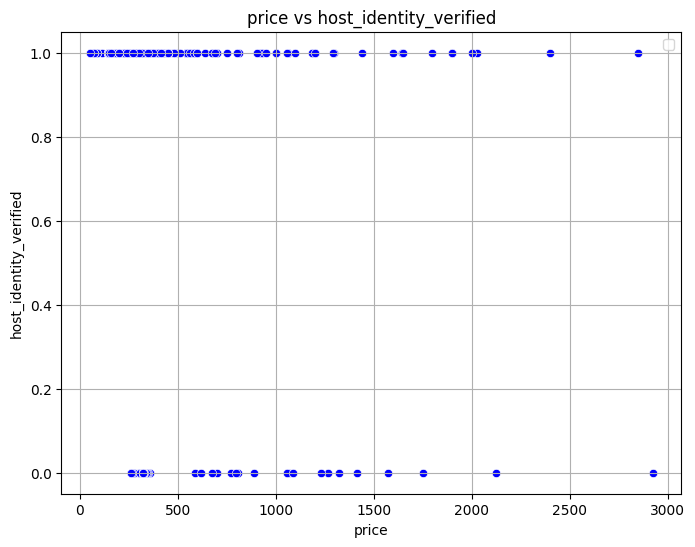

In [5]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='host_identity_verified', x='price',  color = 'blue', data=df)
plt.title('price vs host_identity_verified')
plt.xlabel('price')
plt.ylabel('host_identity_verified')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
indep= df[['host_identity_verified']]
dep = df[['price']]

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [8]:
model.fit(indep, dep)

LinearRegression()

In [9]:
type(model)

sklearn.linear_model._base.LinearRegression

In [10]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-173.97942808]]),
 'rank_': 1,
 'singular_': array([7.64388172]),
 'intercept_': array([583.0915493])}

In [11]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-173.97942808]]
Intercepto: [583.0915493]
y = [-173.97942808]x + [583.0915493]


In [13]:
r2 = model.score(indep, dep)
r2

0.02635429843722703

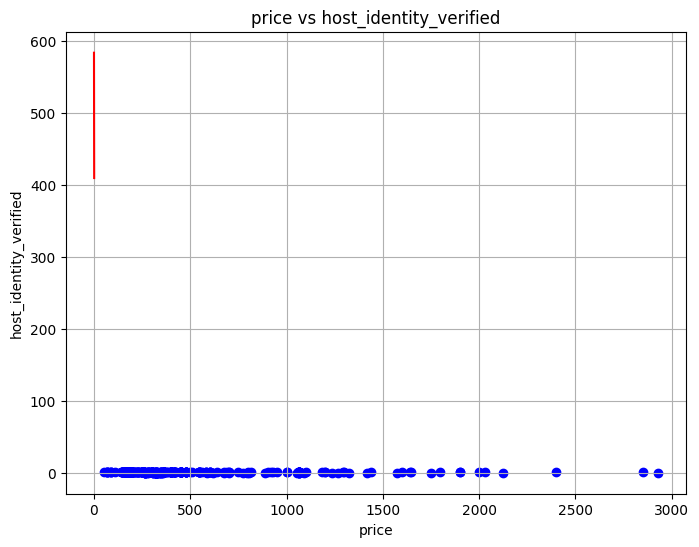

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs host_identity_verified')
plt.xlabel('price')
plt.ylabel('host_identity_verified')
plt.grid(True)
plt.show()

In [15]:
yPred = model.predict(df[['host_identity_verified']])
yPred

array([[583.0915493 ],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [583.0915493 ],
       [409.11212121],
       [409.11212121],
       [583.0915493 ],
       [583.0915493 ],
       [409.11212121],
       [583.0915493 ],
       [583.0915493 ],
       [583.0915493 ],
       [409.11212121],
       [583.0915493 ],
       [409.11212121],
       [409.11212121],
       [583.0915493 ],
       [409.11212121],
       [583.0915493 ],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409.11212121],
       [409

In [16]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
114,115,617137,3059169,1,1,previous scrape,Apt near Mexico City's downtown,No description,No neighborhood_overview,Andoni,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.135,583.091549
257,258,3197924,16186468,2,2,city scrape,cuarto con terraza y uso general,"double bed , full bathroom, room with own terr...",Condesa is the main attraction in the city for...,Jordi,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.195,409.112121
365,366,5434219,28190065,18,1,city scrape,メキシコシティの革命記念塔付近のホステルです。,Single Room $30<br />Double room $60<br />Dorm...,No neighborhood_overview,Tetsuo,...,2.0,4.44,4.74,4.47,4.74,4.71,4.71,4.59,0.300,409.112121
443,444,6972071,35406862,16,1,city scrape,SUPER SAVER GROUP DEAL - PERFECT FOR STUDENTS,Welcome to the best college-style dorms in a B...,No neighborhood_overview,Thor,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.165,409.112121
455,456,6076798,31426842,12,1,city scrape,Nova House,It has all the comforts to rest if you come fo...,The neighborhood is popular where you can expe...,Antonio,...,0.0,4.85,4.84,4.93,4.94,4.91,4.69,4.93,0.750,409.112121


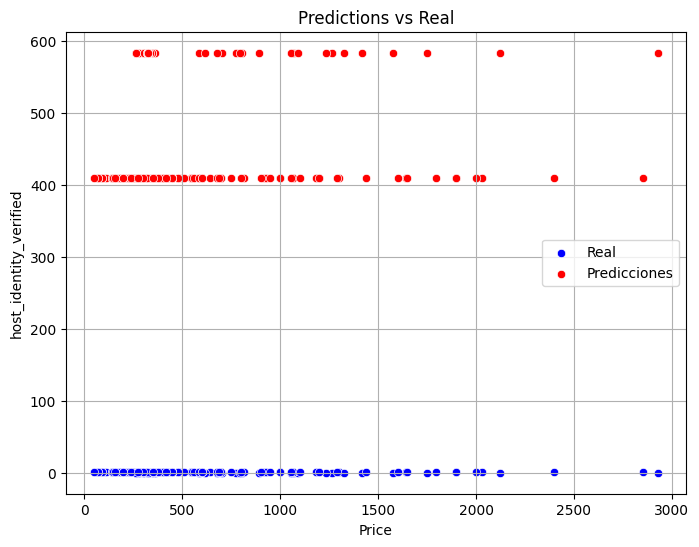

In [17]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='host_identity_verified', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('host_identity_verified')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
coefDe = model.score(indep, dep)
coefDe

0.02635429843722703

In [19]:
coefCo = np.sqrt(coefDe)
coefCo

0.16234007033763115